# Customer Booking Prediction: Analyzing and Improving Model Performance

## Dataset Overview

The dataset used in this project contains customer booking data for a travel company. The target variable we are predicting is whether a customer will complete their booking (`booking_complete`). The dataset consists of multiple features that describe the customer’s behavior and characteristics at the time of booking.

### Key Features:
- **sales_channel**: Channel through which the booking was made (e.g., online, call center).
- **trip_type**: Type of trip (e.g., one-way, round-trip).
- **flight_day**: Day of the flight.
- **route**: The flight route (departure and destination).
- **booking_origin**: Origin of the booking (e.g., country or city).
- **booking_complete**: The target variable indicating whether the booking was completed (1) or not (0).

### Objective:
The goal is to predict whether a customer will complete their booking based on the given features. As the dataset is **imbalanced**, our goal is to apply various machine learning models and improve performance using techniques like **SMOTE (Synthetic Minority Over-sampling Technique)** and **model comparison**.

---

## Approach

The approach followed in this project involves several key stages:

1. **Data Exploration and Preprocessing**: First, we explore and preprocess the data by encoding categorical variables.
2. **Model Application**: Apply multiple machine learning models to predict the target variable.
3. **Hyperparameter Tuning**: Optimize models using **Grid Search CV** for better performance.
4. **Handling Imbalanced Classes**: Apply **SMOTE** to address the class imbalance in the dataset.
5. **Re-evaluation and Performance Comparison**: After using SMOTE, re-evaluate all models to check the impact of the balancing technique.
6. **Visualization**: Visualize the results of model performance before and after SMOTE to analyze the improvements.

---

# Data Exploration and Preprocessing

In the initial step, we load the data and perform **basic exploratory data analysis (EDA)** to get an overview of the dataset's structure. We then encode the categorical columns into numerical values to make the data machine learning-friendly.

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.mixture import GaussianMixture
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import warnings
warnings.simplefilter('ignore')


In [2]:
# Specify the path to your CSV file
file_path = '/kaggle/input/british-airways-customer-booking-data/customer_booking.csv'

# Load the CSV file into a DataFrame
df = pd.read_csv(file_path,  encoding='ISO-8859-1')

# Display the first few rows of the DataFrame to verify
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [4]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


---

# Encoding Categorical Variables
Since machine learning models require numerical inputs, we Label Encode categorical variables. This step converts **textual labels into numerical labels**, allowing us to work with the features effectively. A lot of models like Decision Trees and Random Forest Classifiers perform better after Label Encoding.

---

In [5]:
# Create a list of columns that need to be label encoded
columns_to_encode = ['sales_channel', 'trip_type', 'flight_day', 'route', 'booking_origin']

# Create a LabelEncoder instance
label_encoder = LabelEncoder()

# Create a dictionary to store the labels for each column
encoded_labels = {}

# Loop through the columns, perform label encoding, and store the labels
for column in columns_to_encode:
    # Fit and transform the data
    df[column] = label_encoder.fit_transform(df[column])
    
    # Store the label mapping for each column
    encoded_labels[column] = label_encoder.classes_


# Display the labels for each column
for column, labels in encoded_labels.items():
    print(f"Labels for {column}: {labels}")

Labels for sales_channel: ['Internet' 'Mobile']
Labels for trip_type: ['CircleTrip' 'OneWay' 'RoundTrip']
Labels for flight_day: ['Fri' 'Mon' 'Sat' 'Sun' 'Thu' 'Tue' 'Wed']
Labels for route: ['AKLDEL' 'AKLHGH' 'AKLHND' 'AKLICN' 'AKLKIX' 'AKLKTM' 'AKLKUL' 'AKLMRU'
 'AKLPEK' 'AKLPVG' 'AKLTPE' 'AORICN' 'AORKIX' 'AORKTM' 'AORMEL' 'AORPER'
 'AORPUS' 'BBIMEL' 'BBIOOL' 'BBIPER' 'BBISYD' 'BDOCTS' 'BDOCTU' 'BDOHGH'
 'BDOICN' 'BDOIKA' 'BDOKIX' 'BDOMEL' 'BDOOOL' 'BDOPEK' 'BDOPER' 'BDOPUS'
 'BDOPVG' 'BDOSYD' 'BDOTPE' 'BDOWUH' 'BDOXIY' 'BKICKG' 'BKICTS' 'BKICTU'
 'BKIDEL' 'BKIHND' 'BKIICN' 'BKIKIX' 'BKIKTM' 'BKIMEL' 'BKIMRU' 'BKIOOL'
 'BKIPEK' 'BKIPER' 'BKIPUS' 'BKIPVG' 'BKISYD' 'BKIXIY' 'BLRICN' 'BLRMEL'
 'BLRPER' 'BLRSYD' 'BOMMEL' 'BOMOOL' 'BOMPER' 'BOMSYD' 'BTJJED' 'BTUCKG'
 'BTUICN' 'BTUPER' 'BTUSYD' 'BTUWUH' 'BWNCKG' 'BWNDEL' 'BWNHGH' 'BWNIKA'
 'BWNKTM' 'BWNMEL' 'BWNOOL' 'BWNPER' 'BWNSYD' 'BWNTPE' 'BWNWUH' 'CANDEL'
 'CANIKA' 'CANMEL' 'CANMRU' 'CANOOL' 'CANPER' 'CANSYD' 'CCUMEL' 'CCUMRU'
 'CCUO

In [6]:
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,0,2,262,19,7,2,0,61,1,0,0,5.52,0
1,1,0,2,112,20,3,2,0,61,0,0,0,5.52,0
2,2,0,2,243,22,17,6,0,36,1,1,0,5.52,0
3,1,0,2,96,31,4,2,0,61,0,0,1,5.52,0
4,2,0,2,68,22,15,6,0,36,1,0,1,5.52,0


# Data Exploration: Correlation Matrix

Before applying machine learning models, it's important to understand the relationships between the features in the dataset. The **correlation matrix** provides a useful visualization for identifying correlations between numerical features. In this project, we calculate the **correlation matrix** to understand the degree to which the features are related to each other. This helps us in selecting models that are best suited to the data.


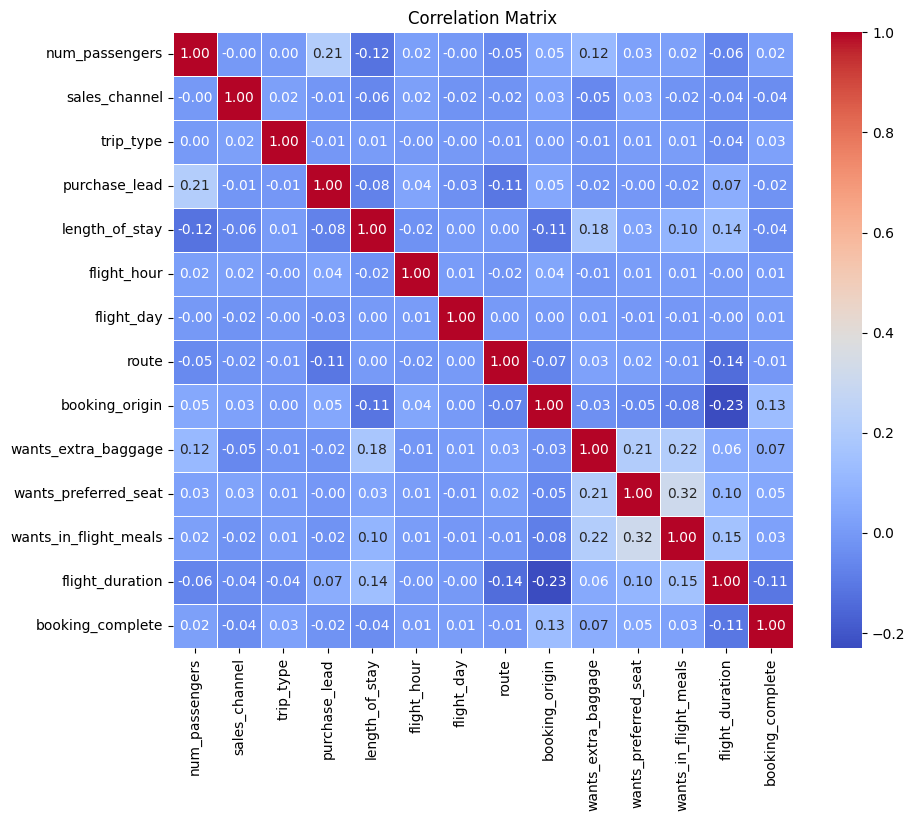

In [7]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


#### Clearly, the data is **not linearly correlated** and hence SVM Classification would be of no use.

# Train-Test Split and Feature Scaling
After encoding the data, we separate the features (X) and the target variable (y). We then split the data into training and testing sets using a **70-30 split**, ensuring that our model can be evaluated on unseen data.
To improve model performance, feature scaling is applied. 

In [8]:
# Separate the features (X) and target (y)
X = df.drop('booking_complete', axis=1)  # Features (all columns except 'booking_complete')
y = df['booking_complete']  # Target variable

# Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize/scale the features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
# Model Application
In this stage, we apply multiple machine learning models to predict whether a customer will complete their booking. The models chosen for initial evaluation are:

**Logistic Regression**: A simple yet powerful linear model for binary classification.

**Naive Bayes**: A probabilistic classifier based on Bayes' Theorem.

**Random Forest**: A powerful ensemble model that combines multiple decision trees.

**Gaussian Mixture Model (GMM)**: A generative model that assumes the data is a mixture of several Gaussian distributions.

**Decision Tree**: A non-linear model that splits the data into decision nodes.

**Support Vector Machine (SVM) with RBF Kernel**: A powerful supervised learning model used for both classification and regression tasks. For binary classification, SVM aims to find the optimal hyperplane that best separates the data into two classes.

We evaluate the models using accuracy, precision, recall, and f1-score metrics, as the dataset is imbalanced, and accuracy alone may not be sufficient.

---


In [9]:
#Firstly, checking if Logistic Regression is able to predict booking
# Initialize the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)

# Train the model
log_reg.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = log_reg.predict(X_test_scaled)

# Evaluate the model
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.8522666666666666

Confusion Matrix:
 [[12784     0]
 [ 2216     0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92     12784
           1       0.00      0.00      0.00      2216

    accuracy                           0.85     15000
   macro avg       0.43      0.50      0.46     15000
weighted avg       0.73      0.85      0.78     15000



In [10]:
#Next, let's experiment with a Naive Bayes Model
# Initialize Naive Bayes model
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_nb = nb_model.predict(X_test_scaled)

# Evaluate the model
print("Naive Bayes Accuracy Score:", accuracy_score(y_test, y_pred_nb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))


Naive Bayes Accuracy Score: 0.8232666666666667

Confusion Matrix:
 [[12120   664]
 [ 1987   229]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90     12784
           1       0.26      0.10      0.15      2216

    accuracy                           0.82     15000
   macro avg       0.56      0.53      0.52     15000
weighted avg       0.77      0.82      0.79     15000



In [11]:
#Checking with Random Forest model
# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate the model
print("Random Forest Accuracy Score:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy Score: 0.8540666666666666

Confusion Matrix:
 [[12582   202]
 [ 1987   229]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.98      0.92     12784
           1       0.53      0.10      0.17      2216

    accuracy                           0.85     15000
   macro avg       0.70      0.54      0.55     15000
weighted avg       0.81      0.85      0.81     15000



In [12]:
#Why not try a Gaussian Mixture Model?
# Initialize GMM model
gmm_model = GaussianMixture(n_components=2, random_state=42)

# Fit GMM model (unsupervised, then predict labels)
gmm_model.fit(X_train_scaled)
y_pred_gmm = gmm_model.predict(X_test_scaled)

# Since GMM doesn't produce 0/1 labels directly, we need to adjust it.
y_pred_gmm = (y_pred_gmm == 1).astype(int)  # Assuming the larger cluster corresponds to class 1

# Evaluate the model
print("GMM Accuracy Score:", accuracy_score(y_test, y_pred_gmm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gmm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gmm))


GMM Accuracy Score: 0.8436

Confusion Matrix:
 [[12649   135]
 [ 2211     5]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.99      0.92     12784
           1       0.04      0.00      0.00      2216

    accuracy                           0.84     15000
   macro avg       0.44      0.50      0.46     15000
weighted avg       0.73      0.84      0.78     15000



In [13]:
#Decision Trees might be better. Let's try
# Initialize Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluate the model
print("Decision Tree Accuracy Score:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))


Decision Tree Accuracy Score: 0.7756666666666666

Confusion Matrix:
 [[10912  1872]
 [ 1493   723]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.87     12784
           1       0.28      0.33      0.30      2216

    accuracy                           0.78     15000
   macro avg       0.58      0.59      0.58     15000
weighted avg       0.79      0.78      0.78     15000



# Addressing Class Imbalance with SMOTE
Since the dataset is highly imbalanced (with more non-booked customers than booked), we use **SMOTE** to generate synthetic samples for the minority class. This helps the models to learn better decision boundaries and improves their performance.

In [14]:
smote = SMOTE(random_state=42)  # You can adjust random_state for reproducibility
X_resampled, y_resampled = smote.fit_resample(X, y)
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['target_column'] = y_resampled

In [15]:
X_train_re, X_test_re, y_train_re, y_test_re = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

# Standardize/scale the features 
scaler = StandardScaler()
X_train_scaled_re = scaler.fit_transform(X_train_re)
X_test_scaled_re = scaler.transform(X_test_re)

# Model Re-Evaluation After SMOTE
Once we apply SMOTE, we re-train all models using the resampled data and re-evaluate their performance. This step is crucial to assess the impact of class balancing on the model performance, especially in terms of recall and f1-score.

In [16]:
# Initialize the Logistic Regression model
log_reg_re = LogisticRegression(max_iter=1000, class_weight='balanced', C=10)

# Train the model
log_reg_re.fit(X_train_scaled_re, y_train_re)

# Predict on the test set
y_pred_re = log_reg_re.predict(X_test_scaled_re)

# Evaluate the model
print("Accuracy Score:", accuracy_score(y_test_re, y_pred_re))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_re, y_pred_re))
print("\nClassification Report:\n", classification_report(y_test_re, y_pred_re))

Accuracy Score: 0.6520341773144156

Confusion Matrix:
 [[7647 5036]
 [3842 8989]]

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.60      0.63     12683
           1       0.64      0.70      0.67     12831

    accuracy                           0.65     25514
   macro avg       0.65      0.65      0.65     25514
weighted avg       0.65      0.65      0.65     25514



In [17]:
# Initialize RandomForest model
rf_model_re = RandomForestClassifier(class_weight='balanced', random_state=42)

# Train the model
rf_model_re.fit(X_train_scaled_re, y_train_re)

# Predict on the test set
y_pred_rf_re = rf_model_re.predict(X_test_scaled_re)

# Evaluate the model
print("Accuracy Score:", accuracy_score(y_test_re, y_pred_rf_re))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_re, y_pred_rf_re))
print("\nClassification Report:\n", classification_report(y_test_re, y_pred_rf_re))

Accuracy Score: 0.8768127302657365

Confusion Matrix:
 [[10948  1735]
 [ 1408 11423]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.86      0.87     12683
           1       0.87      0.89      0.88     12831

    accuracy                           0.88     25514
   macro avg       0.88      0.88      0.88     25514
weighted avg       0.88      0.88      0.88     25514



In [18]:
# Initialize the Naive Bayes model
nb_model_re = GaussianNB()

# Train the model
nb_model_re.fit(X_train_scaled_re, y_train_re)

# Predict on the test set
y_pred_nb_re = nb_model_re.predict(X_test_scaled_re)

# Evaluate the model
print("Naive Bayes Accuracy Score:", accuracy_score(y_test_re, y_pred_nb_re))
print("\nNaive Bayes Confusion Matrix:\n", confusion_matrix(y_test_re, y_pred_nb_re))
print("\nNaive Bayes Classification Report:\n", classification_report(y_test_re, y_pred_nb_re))


Naive Bayes Accuracy Score: 0.6211099788351493

Naive Bayes Confusion Matrix:
 [[ 4440  8243]
 [ 1424 11407]]

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.35      0.48     12683
           1       0.58      0.89      0.70     12831

    accuracy                           0.62     25514
   macro avg       0.67      0.62      0.59     25514
weighted avg       0.67      0.62      0.59     25514



In [19]:
# Initialize the GMM model
gmm_model_re = GaussianMixture(n_components=2, covariance_type='full', random_state=42)

# Fit GMM model to the features (train on X_train_scaled_re)
gmm_model_re.fit(X_train_scaled_re)

# Predict the cluster labels (class prediction)
y_pred_gmm_re = gmm_model_re.predict(X_test_scaled_re)

# Evaluate the model
print("GMM Accuracy Score:", accuracy_score(y_test_re, y_pred_gmm_re))
print("\nGMM Confusion Matrix:\n", confusion_matrix(y_test_re, y_pred_gmm_re))
print("\nGMM Classification Report:\n", classification_report(y_test_re, y_pred_gmm_re))


GMM Accuracy Score: 0.5886964019753861

GMM Confusion Matrix:
 [[6692 5991]
 [4503 8328]]

GMM Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.53      0.56     12683
           1       0.58      0.65      0.61     12831

    accuracy                           0.59     25514
   macro avg       0.59      0.59      0.59     25514
weighted avg       0.59      0.59      0.59     25514



In [20]:
# Initialize the Decision Tree model
dt_model_re = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model_re.fit(X_train_scaled_re, y_train_re)

# Predict on the test set
y_pred_dt_re = dt_model_re.predict(X_test_scaled_re)

# Evaluate the model
print("Decision Tree Accuracy Score:", accuracy_score(y_test_re, y_pred_dt_re))
print("\nDecision Tree Confusion Matrix:\n", confusion_matrix(y_test_re, y_pred_dt_re))
print("\nDecision Tree Classification Report:\n", classification_report(y_test_re, y_pred_dt_re))


Decision Tree Accuracy Score: 0.8218233126910716

Decision Tree Confusion Matrix:
 [[10117  2566]
 [ 1980 10851]]

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.80      0.82     12683
           1       0.81      0.85      0.83     12831

    accuracy                           0.82     25514
   macro avg       0.82      0.82      0.82     25514
weighted avg       0.82      0.82      0.82     25514



In [22]:
# Initialize the SVM model with RBF kernel
svm_rbf_re = SVC(kernel='rbf', random_state=42)

# Train the SVM model on the resampled (SMOTE) data
svm_rbf_re.fit(X_train_scaled_re, y_train_re)

# Predict on the test set
y_pred_svm_rbf_re = svm_rbf_re.predict(X_test_scaled_re)

# Evaluate the model
print("SVM (RBF Kernel) Accuracy Score:", accuracy_score(y_test_re, y_pred_svm_rbf_re))
print("\nSVM (RBF Kernel) Confusion Matrix:\n", confusion_matrix(y_test_re, y_pred_svm_rbf_re))
print("\nSVM (RBF Kernel) Classification Report:\n", classification_report(y_test_re, y_pred_svm_rbf_re))


SVM (RBF Kernel) Accuracy Score: 0.7237986987536255

SVM (RBF Kernel) Confusion Matrix:
 [[ 8379  4304]
 [ 2743 10088]]

SVM (RBF Kernel) Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.66      0.70     12683
           1       0.70      0.79      0.74     12831

    accuracy                           0.72     25514
   macro avg       0.73      0.72      0.72     25514
weighted avg       0.73      0.72      0.72     25514



# Visualising the Model Performances

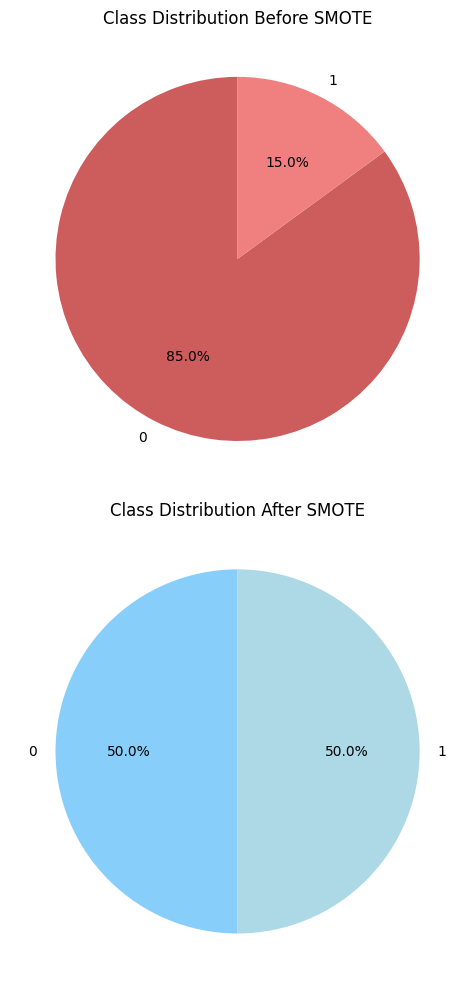

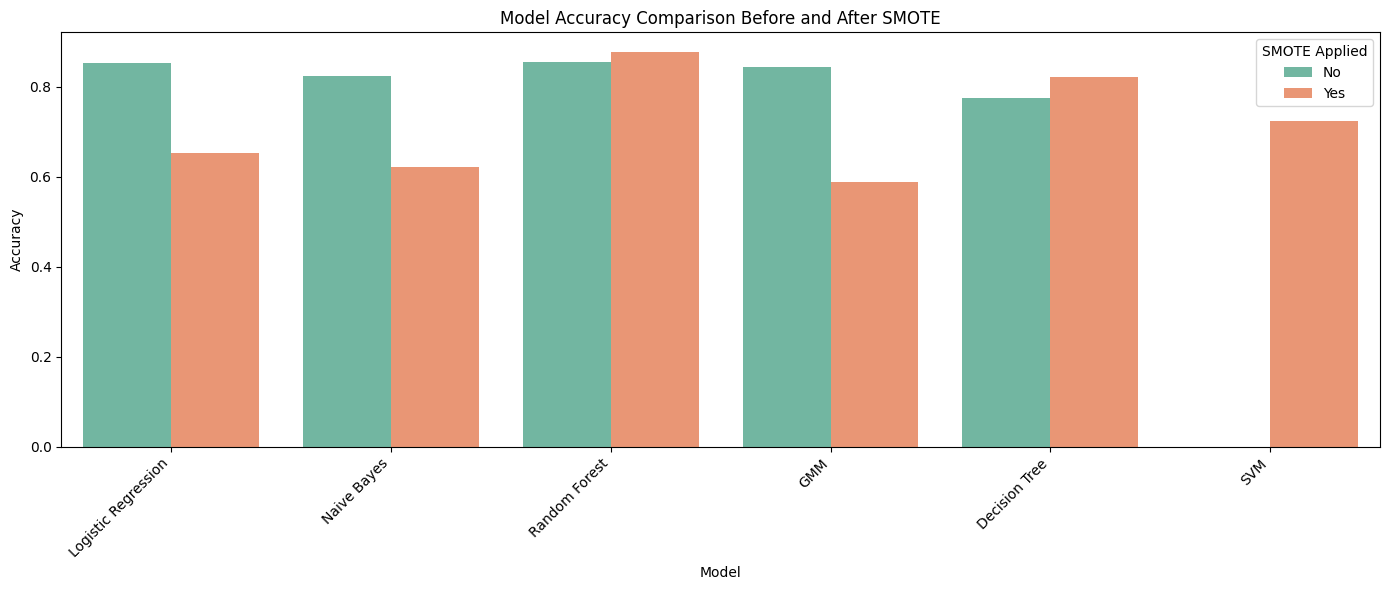

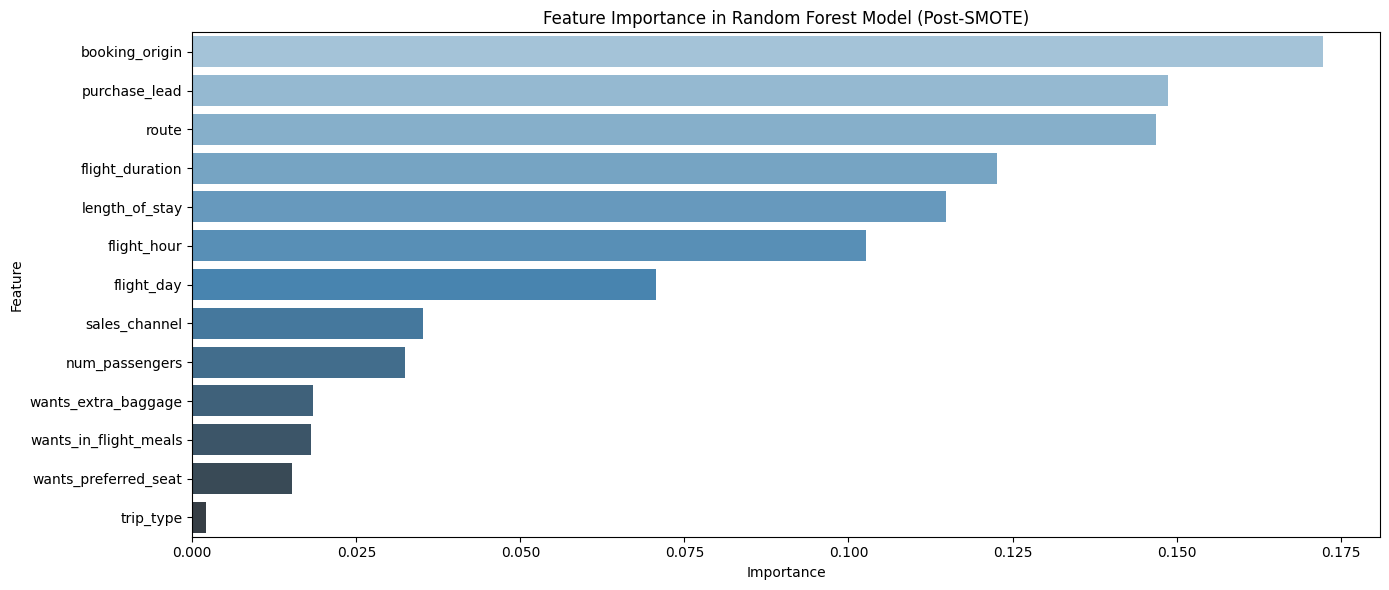

In [24]:
# Calculate class distribution before SMOTE
before_smote = y.value_counts().sort_index()

# Calculate class distribution after SMOTE
after_smote = y_resampled.value_counts().sort_index()

# Model accuracy calculation before SMOTE
accuracies_before_smote = {
    "Logistic Regression": accuracy_score(y_test, y_pred),
    "Naive Bayes": accuracy_score(y_test, y_pred_nb),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "GMM": accuracy_score(y_test, y_pred_gmm),
    "Decision Tree": accuracy_score(y_test, y_pred_dt)
}

# Adding SVM to the accuracy calculations after SMOTE
accuracies_after_smote = {
    "Logistic Regression": accuracy_score(y_test_re, y_pred_re),
    "Naive Bayes": accuracy_score(y_test_re, y_pred_nb_re),
    "Random Forest": accuracy_score(y_test_re, y_pred_rf_re),
    "GMM": accuracy_score(y_test_re, y_pred_gmm_re),
    "Decision Tree": accuracy_score(y_test_re, y_pred_dt_re),
    "SVM": accuracy_score(y_test_re, y_pred_svm_rbf_re)  # SVM added
}

# Convert model accuracy to a DataFrame for comparison
accuracy_df = pd.DataFrame({
    "Model": list(accuracies_before_smote.keys()) + list(accuracies_after_smote.keys()),
    "Accuracy": list(accuracies_before_smote.values()) + list(accuracies_after_smote.values()),
    "SMOTE Applied": ["No"] * len(accuracies_before_smote) + ["Yes"] * len(accuracies_after_smote)
})

# Plotting the visualizations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))  # Increased height to avoid overlap

# 1. Plot the class distribution before SMOTE as a pie chart
ax1.pie(before_smote, labels=before_smote.index, autopct='%1.1f%%', colors=['indianred', 'lightcoral'], startangle=90)
ax1.set_title("Class Distribution Before SMOTE")

# 2. Plot the class distribution after SMOTE as a pie chart
ax2.pie(after_smote, labels=after_smote.index, autopct='%1.1f%%', colors=['lightskyblue', 'lightblue'], startangle=90)
ax2.set_title("Class Distribution After SMOTE")

# Adjust the layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()

# Model accuracy comparison plot (already in previous code)
fig, ax3 = plt.subplots(figsize=(14, 6))

sns.barplot(x="Model", y="Accuracy", hue="SMOTE Applied", data=accuracy_df, ax=ax3, palette="Set2")
ax3.set_title("Model Accuracy Comparison Before and After SMOTE")
ax3.set_xlabel("Model")
ax3.set_ylabel("Accuracy")
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha="right")  # Rotate labels for better fit

plt.tight_layout()
plt.show()

# Extract feature importances from the trained RandomForest model
feature_importance = rf_model_re.feature_importances_

# Create a DataFrame for feature importances
feature_df = pd.DataFrame({
    'Feature': df.columns.drop('booking_complete'),  # Features in the training set
    'Importance': feature_importance
})

# Sort the features by importance in descending order
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(14, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette="Blues_d")
plt.title("Feature Importance in Random Forest Model (Post-SMOTE)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# Conclusion

Random Forrest Classifier clealy has a superior performance in case of this dataset. Despite SMOTE, we were not really able to significatly boost the accuracy.